# New

In [14]:
import os
# Disables the Hugging Face progress bars to prevent ipywidgets errors
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

In [15]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MultiLabelBinarizer
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

# 1. Load FMA tracks metadata (multi-index CSV)
tracks = pd.read_csv(
    "/kaggle/input/fma-free-music-archive-small-medium/fma_metadata/tracks.csv",
    index_col=0,
    header=[0, 1],
)

# 2. Extract relevant subset (e.g., 'medium' or 'small')
subset = tracks["set", "subset"] <= "medium"
tracks = tracks[subset]

# 3. Create input text strings
tracks["text"] = (
    "Title: "
    + tracks["track", "title"].fillna("Unknown")
    + ". Artist: "
    + tracks["artist", "name"].fillna("Unknown")
)

# 4. Extract labels and split
split = tracks["set", "split"]
train_df = tracks[split == "training"]
val_df = tracks[split == "validation"]
test_df = tracks[split == "test"]

In [16]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


class MusicTextDataset(Dataset):

  def __init__(self, texts, labels, tokenizer, max_len=128):
    self.texts = list(texts)
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = self.texts[idx]
    encoding = self.tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=self.max_len,
        return_tensors="pt",
    )
    item = {key: val.squeeze(0) for key, val in encoding.items()}
    item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
    return item

In [17]:
# Test to ensure it loaded correctly
test_tokens = tokenizer("Testing the tokenizer")
print(test_tokens)

{'input_ids': [101, 5604, 1996, 19204, 17629, 102], 'attention_mask': [1, 1, 1, 1, 1, 1]}


In [18]:
import torch.nn as nn


class BertTagClassifier(nn.Module):

  def __init__(self, model_name="distilbert-base-uncased", num_classes=16):
    super().__init__()
    self.bert = AutoModel.from_pretrained(model_name)
    hidden_size = self.bert.config.hidden_size
    self.classifier = nn.Linear(hidden_size, num_classes)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    # Extract CLS token embedding (first token)
    cls_rep = outputs.last_hidden_state[:, 0, :]
    logits = self.classifier(cls_rep)
    return logits

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Prepare the labels: convert the 'genre_top' column into lists
train_genres = train_df[("track", "genre_top")].fillna("Unknown").apply(lambda x: [x])
val_genres = val_df[("track", "genre_top")].fillna("Unknown").apply(lambda x: [x])

# 2. Binarize the labels (creates the 1s and 0s vector for the multi-label BCE loss)
mlb = MultiLabelBinarizer()
train_labels = mlb.fit_transform(train_genres)
val_labels = mlb.transform(val_genres)

# Update the num_classes in your model to match the number of unique genres detected
num_classes = len(mlb.classes_)
print(f"Detected {num_classes} unique labels/genres.")

# 3. Create the PyTorch Dataset objects
train_dataset = MusicTextDataset(train_df["text"].values, train_labels, tokenizer)
val_dataset = MusicTextDataset(val_df["text"].values, val_labels, tokenizer)

Detected 17 unique labels/genres.


In [20]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn as nn
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Assuming train_dataset and val_dataset were created using the MusicTextDataset class
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Pass the dynamically calculated num_classes (which is 17)
model = BertTagClassifier(num_classes=num_classes).to(device) 

# Make sure to also re-initialize the optimizer so it registers the new model parameters
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss() # This handles the sigmoid internally

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_projector.bias', 'vocab_projector.weight', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [21]:
epochs = 3
history = {'macro_f1': [], 'micro_f1': []}

for epoch in range(epochs):
    model.train()
    print(f"\n--- Starting Epoch {epoch+1}/{epochs} [Training] ---")
    
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        # Print an update every 50 batches so you know it's alive
        if step % 50 == 0:
            print(f"  Batch {step}/{len(train_loader)} | Loss: {loss.item():.4f}")
            
    # Validation Phase
    model.eval()
    all_preds, all_labels = [], []
    
    print(f"--- Starting Epoch {epoch+1}/{epochs} [Validation] ---")
    
    with torch.no_grad():
        for step, batch in enumerate(val_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].cpu().numpy()
            
            logits = model(input_ids, attention_mask)
            preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(int)
            
            all_preds.extend(preds)
            all_labels.extend(labels)
            
            if step % 50 == 0:
                print(f"  Validating Batch {step}/{len(val_loader)}")
            
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    
    history['macro_f1'].append(macro_f1)
    history['micro_f1'].append(micro_f1)
    
    print(f"\n--> Epoch {epoch+1} Results | Macro-F1: {macro_f1:.4f} | Micro-F1: {micro_f1:.4f}\n")


--- Starting Epoch 1/3 [Training] ---
  Batch 0/4873 | Loss: 0.6951
  Batch 50/4873 | Loss: 0.1932
  Batch 100/4873 | Loss: 0.1374
  Batch 150/4873 | Loss: 0.1375
  Batch 200/4873 | Loss: 0.1191
  Batch 250/4873 | Loss: 0.1598
  Batch 300/4873 | Loss: 0.1600
  Batch 350/4873 | Loss: 0.1470
  Batch 400/4873 | Loss: 0.1301
  Batch 450/4873 | Loss: 0.1368
  Batch 500/4873 | Loss: 0.1027
  Batch 550/4873 | Loss: 0.1077
  Batch 600/4873 | Loss: 0.1166
  Batch 650/4873 | Loss: 0.1384
  Batch 700/4873 | Loss: 0.1193
  Batch 750/4873 | Loss: 0.0955
  Batch 800/4873 | Loss: 0.1383
  Batch 850/4873 | Loss: 0.1082
  Batch 900/4873 | Loss: 0.1718
  Batch 950/4873 | Loss: 0.1371
  Batch 1000/4873 | Loss: 0.0904
  Batch 1050/4873 | Loss: 0.0715
  Batch 1100/4873 | Loss: 0.0833
  Batch 1150/4873 | Loss: 0.1262
  Batch 1200/4873 | Loss: 0.1134
  Batch 1250/4873 | Loss: 0.1424
  Batch 1300/4873 | Loss: 0.1137
  Batch 1350/4873 | Loss: 0.1046
  Batch 1400/4873 | Loss: 0.1489
  Batch 1450/4873 | Loss: 0

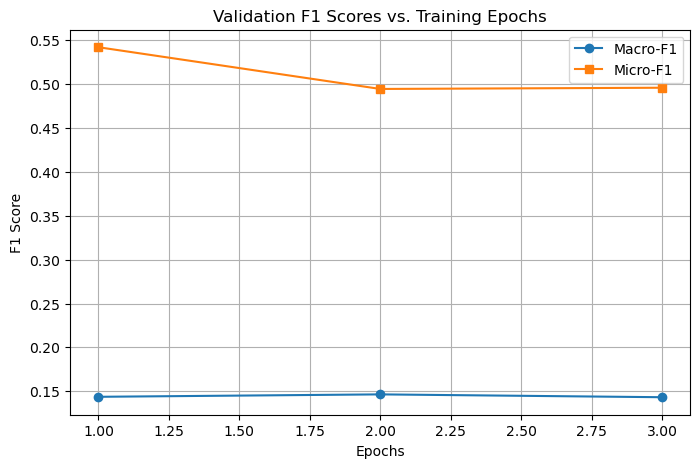


--- 5 Example Predictions ---

Example 1:
Ground Truth Labels : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Predicted Labels    : [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]

Example 2:
Ground Truth Labels : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted Labels    : [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]

Example 3:
Ground Truth Labels : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted Labels    : [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]

Example 4:
Ground Truth Labels : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted Labels    : [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]

Example 5:
Ground Truth Labels : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Predicted Labels    : [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [22]:
# Plotting the F1 Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), history['macro_f1'], label='Macro-F1', marker='o')
plt.plot(range(1, epochs+1), history['micro_f1'], label='Micro-F1', marker='s')
plt.title('Validation F1 Scores vs. Training Epochs')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

# 5 Example Predictions
print("\n--- 5 Example Predictions ---")
for i in range(5):
    print(f"\nExample {i+1}:")
    print(f"Ground Truth Labels : {all_labels[i]}")
    print(f"Predicted Labels    : {all_preds[i]}")